# CYBERSECURITY — NETWORK INTRUSION DETECTION
---

### Topics Covered
- Data Loading & Inspection
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Statistical Analysis (T-tests, Chi-Square, ANOVA)
- Correlation & Feature Importance
- Machine Learning: Logistic Regression & Random Forest
- Model Evaluation: ROC-AUC, Confusion Matrix, Cross-Validation


Shape: (5000, 18)

Column names:
 ['duration', 'protocol_type', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'num_root', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'flag', 'attack_type', 'target']

Data types:
 duration             float64
protocol_type         object
src_bytes              int64
dst_bytes              int64
land                   int64
wrong_fragment         int64
urgent                 int64
num_failed_logins      int64
logged_in              int64
num_compromised        int64
root_shell             int64
num_root               int64
serror_rate          float64
rerror_rate          float64
same_srv_rate        float64
flag                  object
attack_type           object
target                 int64
dtype: object

First 5 rows:
    duration protocol_type  src_bytes  dst_bytes  land  wrong_fragment  urgent  \
0    2.5014           tcp       1897       2231     0               

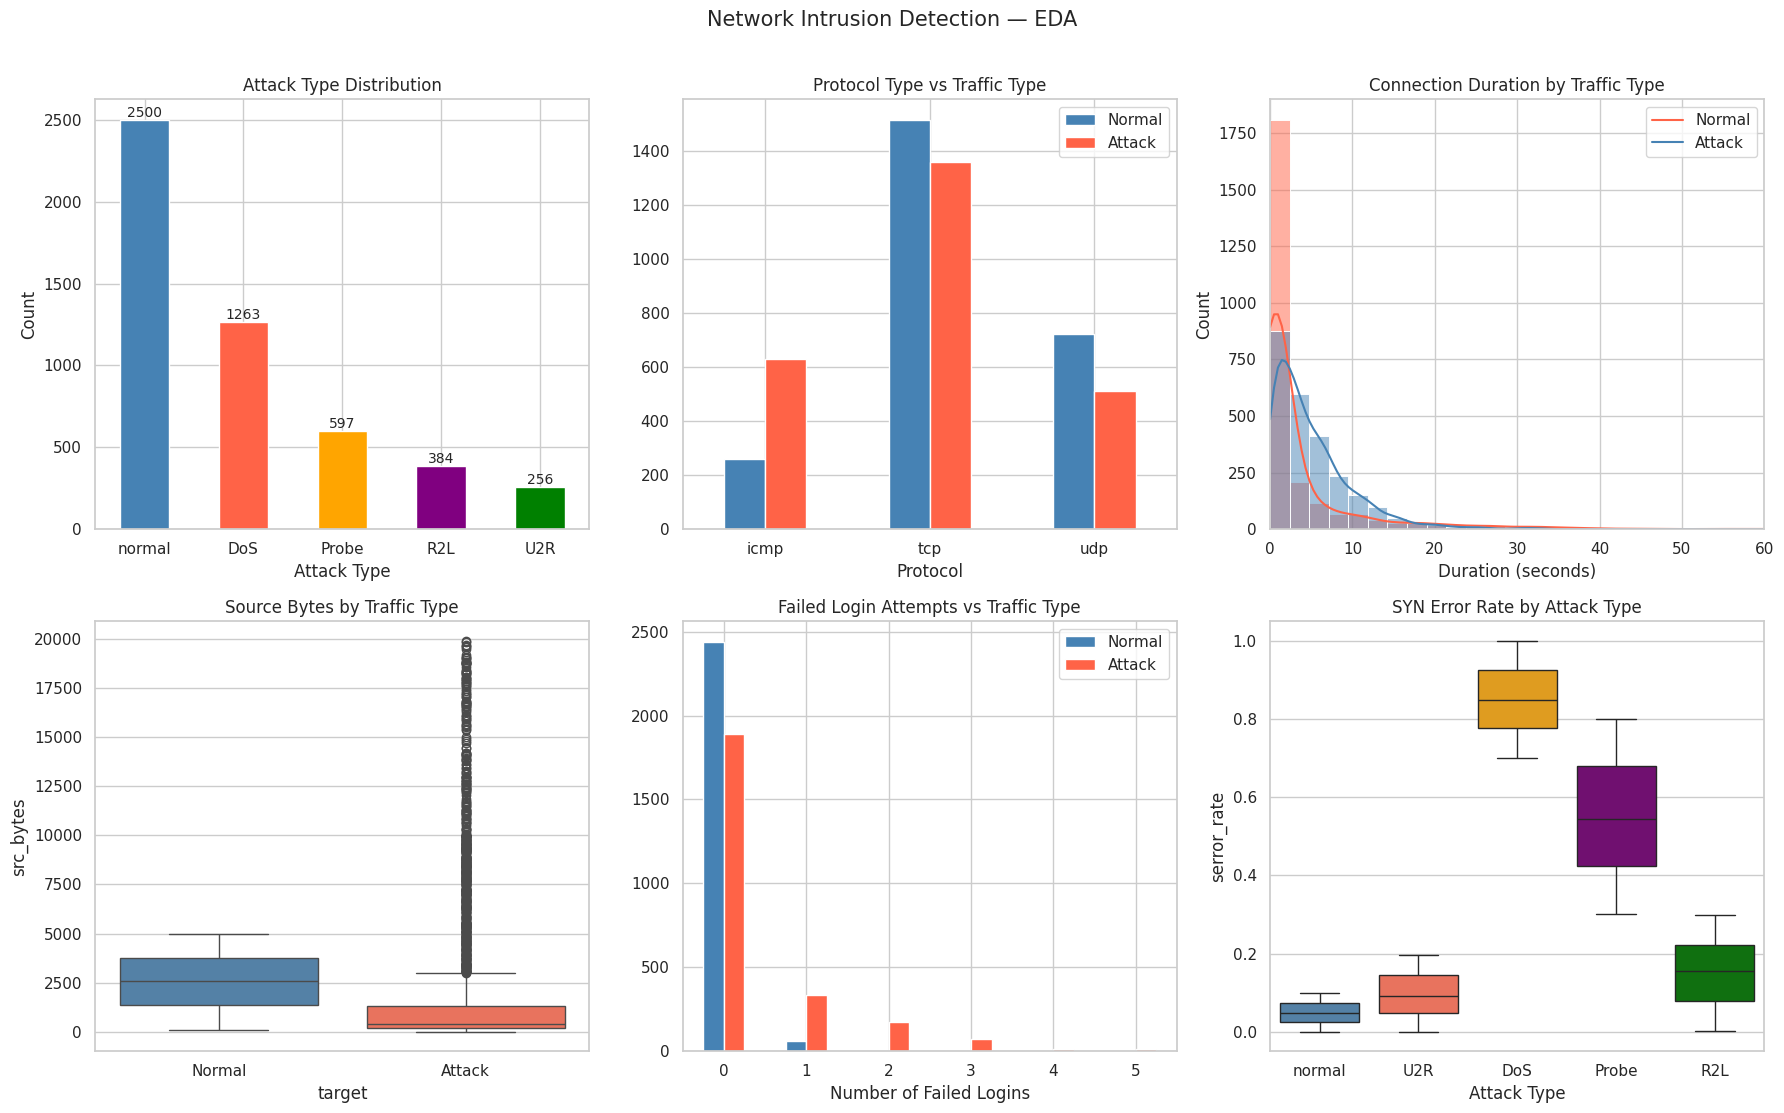

=== Key Statistical Findings ===

Duration — Normal mean: 5.09, Attack mean: 3.87
T-statistic: 6.1892, p-value: 0.0000 → Significant

Src Bytes — Normal mean: 2562.21, Attack mean: 2210.89
T-statistic: 4.1108, p-value: 0.0000 → Significant

Serror Rate — Normal mean: 0.0493, Attack mean: 0.5929
T-statistic: -85.8464, p-value: 0.0000 → Significant

Failed Logins — Normal mean: 0.0244, Attack mean: 0.4104
T-statistic: -22.1666, p-value: 0.0000 → Significant

Protocol Type vs Target — Chi2: 196.53, p-value: 0.0000, dof: 2
Result: Significant association

Logged In vs Target — Chi2: 1313.67, p-value: 0.0000, dof: 1
Result: Significant association



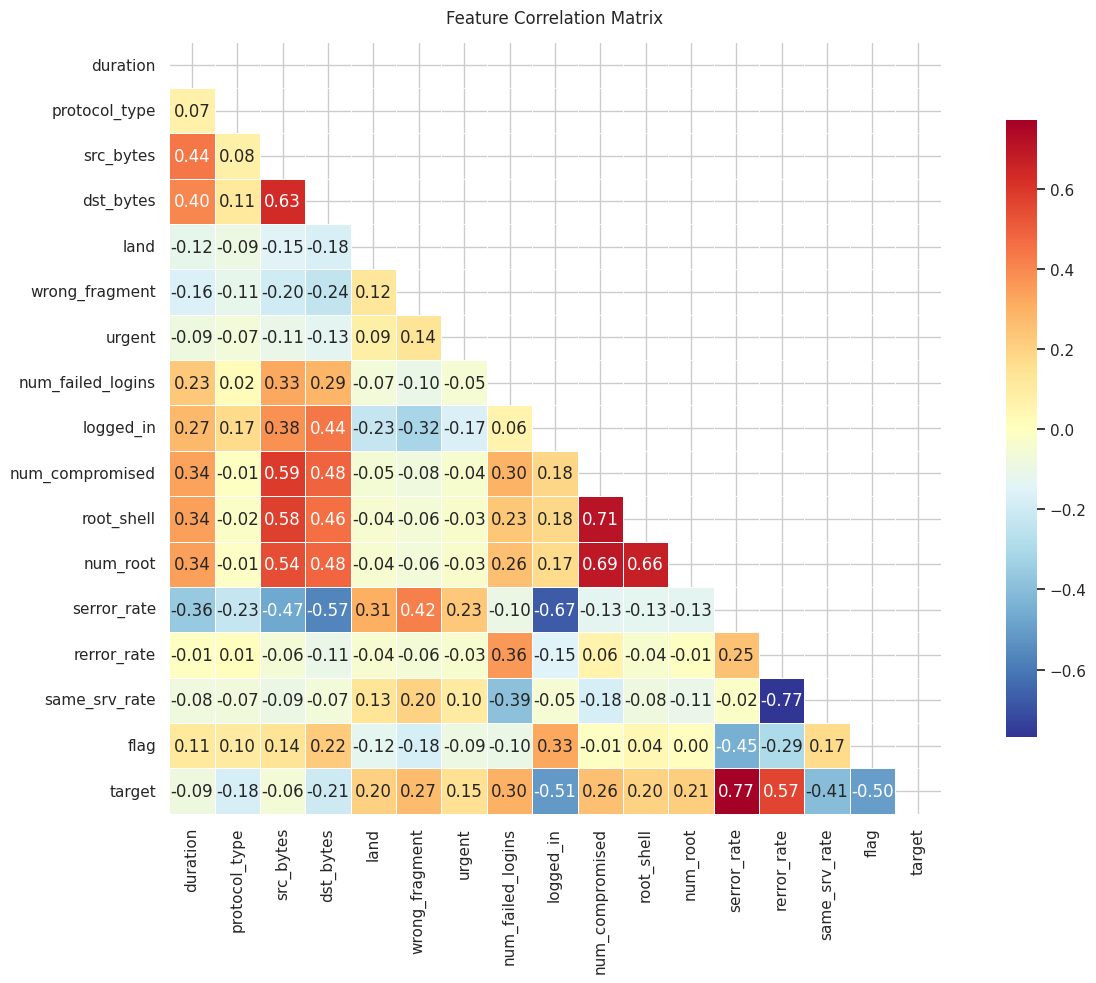


Correlation with Target (sorted):
logged_in           -0.513
flag                -0.500
same_srv_rate       -0.405
dst_bytes           -0.208
protocol_type       -0.178
duration            -0.087
src_bytes           -0.058
urgent               0.152
root_shell           0.198
land                 0.205
num_root             0.212
num_compromised      0.258
wrong_fragment       0.269
num_failed_logins    0.299
rerror_rate          0.567
serror_rate          0.772
Name: target, dtype: float64


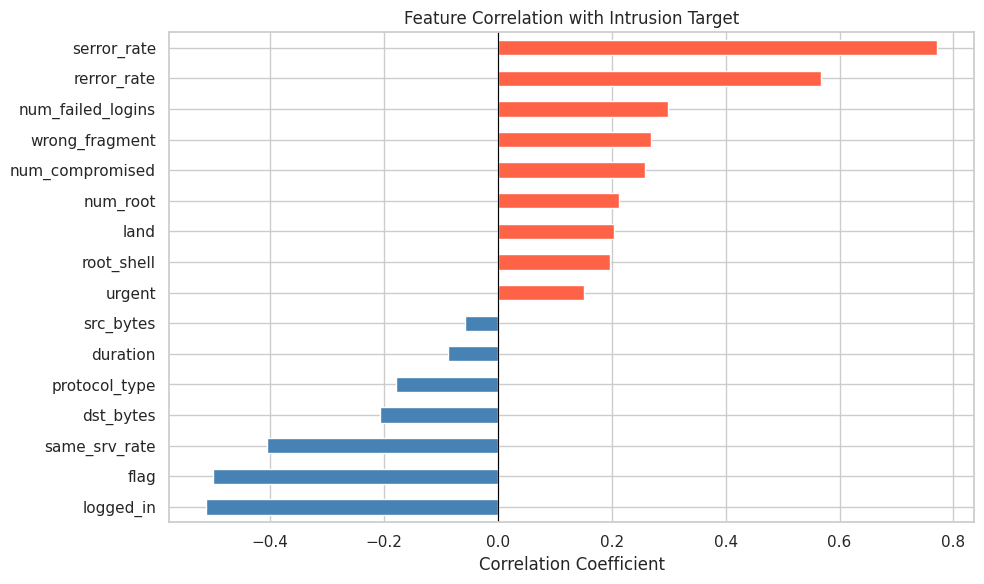

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='muted')

# PHASE 1 — LOAD & UNDERSTAND


In [5]:
df = pd.read_csv('network_intrusion.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nBasic statistics:\n", df.describe())
print("\nMissing values:\n", df.isnull().sum())

print("\nTarget distribution:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(2))

print("\nAttack type distribution:")
print(df['attack_type'].value_counts())

Shape: (5000, 18)

Column names:
 ['duration', 'protocol_type', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'num_root', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'flag', 'attack_type', 'target']

Data types:
 duration             float64
protocol_type         object
src_bytes              int64
dst_bytes              int64
land                   int64
wrong_fragment         int64
urgent                 int64
num_failed_logins      int64
logged_in              int64
num_compromised        int64
root_shell             int64
num_root               int64
serror_rate          float64
rerror_rate          float64
same_srv_rate        float64
flag                  object
attack_type           object
target                 int64
dtype: object

First 5 rows:
    duration protocol_type  src_bytes  dst_bytes  land  wrong_fragment  urgent  \
0    2.5014           tcp       1897       2231     0               

# PHASE 2 — DATA PREPROCESSING

In [ ]:
categorical_cols = ['protocol_type', 'flag']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("After encoding:")
print(df[['protocol_type', 'flag']].head())

# --- Step 2: Separate features and target ---
# Drop attack_type (it directly reveals the answer — data leakage)
# Drop target (that's what we predict)
X = df.drop(['target', 'attack_type'], axis=1)
y = df['target']

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:\n", X.columns.tolist())

# --- Step 3: Train test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size: ", X_test.shape)

# --- Step 4: Scale features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# PHASE 3 — EXPLORATORY DATA ANALYSIS

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Attack type distribution
attack_counts = df['attack_type'].value_counts()
colors = ['steelblue', 'tomato', 'orange', 'purple', 'green']
attack_counts.plot(kind='bar', ax=axes[0,0], color=colors, rot=0)
axes[0,0].set_title('Attack Type Distribution')
axes[0,0].set_xlabel('Attack Type')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(attack_counts):
    axes[0,0].text(i, v + 20, str(v), ha='center', fontsize=10)

# 2. Protocol type vs target
proto_map = {0: 'icmp', 1: 'tcp', 2: 'udp'}
df['protocol_label'] = df['protocol_type'].map(proto_map)
proto_counts = df.groupby(['protocol_label', 'target']).size().unstack()
proto_counts.plot(kind='bar', ax=axes[0,1],
                  color=['steelblue', 'tomato'], rot=0)
axes[0,1].set_title('Protocol Type vs Traffic Type')
axes[0,1].set_xlabel('Protocol')
axes[0,1].legend(['Normal', 'Attack'])

# 3. Duration distribution by target
sns.histplot(data=df, x='duration', hue='target', bins=40,
             ax=axes[0,2], kde=True,
             palette=['steelblue', 'tomato'])
axes[0,2].set_title('Connection Duration by Traffic Type')
axes[0,2].set_xlabel('Duration (seconds)')
axes[0,2].legend(['Normal', 'Attack'])
axes[0,2].set_xlim(0, 60)

# 4. Source bytes by target
sns.boxplot(data=df, x='target', y='src_bytes', ax=axes[1,0],
            hue='target', palette=['steelblue', 'tomato'], legend=False)
axes[1,0].set_title('Source Bytes by Traffic Type')
axes[1,0].set_xticks([0, 1])
axes[1,0].set_xticklabels(['Normal', 'Attack'])

# 5. Failed logins by target
failed_counts = df.groupby(['num_failed_logins', 'target']).size().unstack().fillna(0)
failed_counts.plot(kind='bar', ax=axes[1,1],
                   color=['steelblue', 'tomato'], rot=0)
axes[1,1].set_title('Failed Login Attempts vs Traffic Type')
axes[1,1].set_xlabel('Number of Failed Logins')
axes[1,1].legend(['Normal', 'Attack'])

# 6. Serror rate by attack type
sns.boxplot(data=df, x='attack_type', y='serror_rate', ax=axes[1,2],
            hue='attack_type',
            palette=['steelblue','tomato','orange','purple','green'],
            legend=False)
axes[1,2].set_title('SYN Error Rate by Attack Type')
axes[1,2].set_xlabel('Attack Type')

plt.suptitle('Network Intrusion Detection — EDA', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temporary column
df.drop('protocol_label', axis=1, inplace=True)

# PHASE 4 — STATISTICAL ANALYSIS

In [ ]:
print("=== Key Statistical Findings ===\n")

# T-test: duration
normal_dur  = df[df['target'] == 0]['duration']
attack_dur  = df[df['target'] == 1]['duration']
t_dur, p_dur = stats.ttest_ind(normal_dur, attack_dur)
print(f"Duration — Normal mean: {normal_dur.mean():.2f}, Attack mean: {attack_dur.mean():.2f}")
print(f"T-statistic: {t_dur:.4f}, p-value: {p_dur:.4f} → {'Significant' if p_dur < 0.05 else 'Not significant'}\n")

# T-test: src_bytes
normal_src  = df[df['target'] == 0]['src_bytes']
attack_src  = df[df['target'] == 1]['src_bytes']
t_src, p_src = stats.ttest_ind(normal_src, attack_src)
print(f"Src Bytes — Normal mean: {normal_src.mean():.2f}, Attack mean: {attack_src.mean():.2f}")
print(f"T-statistic: {t_src:.4f}, p-value: {p_src:.4f} → {'Significant' if p_src < 0.05 else 'Not significant'}\n")

# T-test: serror_rate
normal_ser  = df[df['target'] == 0]['serror_rate']
attack_ser  = df[df['target'] == 1]['serror_rate']
t_ser, p_ser = stats.ttest_ind(normal_ser, attack_ser)
print(f"Serror Rate — Normal mean: {normal_ser.mean():.4f}, Attack mean: {attack_ser.mean():.4f}")
print(f"T-statistic: {t_ser:.4f}, p-value: {p_ser:.4f} → {'Significant' if p_ser < 0.05 else 'Not significant'}\n")

# T-test: num_failed_logins
normal_fl   = df[df['target'] == 0]['num_failed_logins']
attack_fl   = df[df['target'] == 1]['num_failed_logins']
t_fl, p_fl  = stats.ttest_ind(normal_fl, attack_fl)
print(f"Failed Logins — Normal mean: {normal_fl.mean():.4f}, Attack mean: {attack_fl.mean():.4f}")
print(f"T-statistic: {t_fl:.4f}, p-value: {p_fl:.4f} → {'Significant' if p_fl < 0.05 else 'Not significant'}\n")

# Chi-square: protocol_type vs target
contingency_proto = pd.crosstab(df['protocol_type'], df['target'])
chi2_p, p_chi_p, dof_p, _ = stats.chi2_contingency(contingency_proto)
print(f"Protocol Type vs Target — Chi2: {chi2_p:.2f}, p-value: {p_chi_p:.4f}, dof: {dof_p}")
print(f"Result: {'Significant association' if p_chi_p < 0.05 else 'No association'}\n")

# Chi-square: logged_in vs target
contingency_li = pd.crosstab(df['logged_in'], df['target'])
chi2_li, p_chi_li, dof_li, _ = stats.chi2_contingency(contingency_li)
print(f"Logged In vs Target — Chi2: {chi2_li:.2f}, p-value: {p_chi_li:.4f}, dof: {dof_li}")
print(f"Result: {'Significant association' if p_chi_li < 0.05 else 'No association'}\n")

# PHASE 5 — CORRELATION ANALYSIS

In [ ]:
# PHASE 5 — CORRELATION ANALYSIS
plt.figure(figsize=(14, 10))
corr = df[X.columns.tolist() + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', pad=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr['target'].drop('target').sort_values()
print("\nCorrelation with Target (sorted):")
print(target_corr.round(3))

# Bar chart of correlations
plt.figure(figsize=(10, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Intrusion Target')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# PHASE 6 — MODEL BUILDING & EVALUATION


In [ ]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred  = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred,
      target_names=['Normal', 'Attack']))
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_proba):.3f}\n")

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Model 2: Decision Tree ---
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred  = dt.predict(X_test_scaled)
dt_proba = dt.predict_proba(X_test_scaled)[:, 1]

print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred,
      target_names=['Normal', 'Attack']))
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, dt_proba):.3f}\n")

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d',
            cmap='Oranges', xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_decisiontree.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Model 3: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred  = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred,
      target_names=['Normal', 'Attack']))
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}\n")

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_randomforest.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cross Validation using Pipeline ---
lr_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', LogisticRegression(max_iter=1000, random_state=42))])
dt_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', DecisionTreeClassifier(max_depth=10, random_state=42))])
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', RandomForestClassifier(n_estimators=100, random_state=42))])

cv_lr = cross_val_score(lr_pipe, X, y, cv=5, scoring='accuracy')
cv_dt = cross_val_score(dt_pipe, X, y, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf_pipe, X, y, cv=5, scoring='accuracy')

print("=== 5-Fold Cross Validation Accuracy ===")
print(f"Logistic Regression : {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")
print(f"Decision Tree       : {cv_dt.mean():.3f} ± {cv_dt.std():.3f}")
print(f"Random Forest       : {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

# --- ROC Curve — all 3 models ---
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in [
    ('Logistic Regression', lr_proba),
    ('Decision Tree',       dt_proba),
    ('Random Forest',       rf_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})', linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Model Comparison Bar Chart ---
model_names  = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies   = [accuracy_score(y_test, lr_pred),
                accuracy_score(y_test, dt_pred),
                accuracy_score(y_test, rf_pred)]
roc_scores   = [roc_auc_score(y_test, lr_proba),
                roc_auc_score(y_test, dt_proba),
                roc_auc_score(y_test, rf_proba)]

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x + width/2, roc_scores, width, label='ROC-AUC',   color='tomato')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy vs ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# PHASE 7 — FEATURE IMPORTANCE


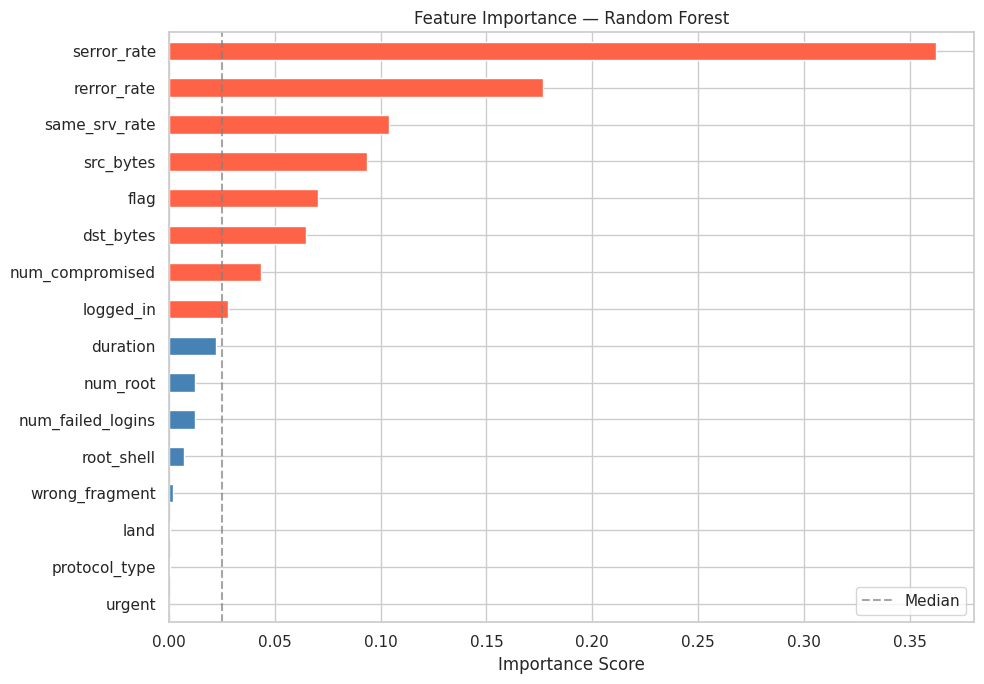


Top 5 most important features:
serror_rate      0.362344
rerror_rate      0.176740
same_srv_rate    0.103828
src_bytes        0.093468
flag             0.070404
dtype: float64

=== All phases complete. All charts saved. ===


In [3]:

feat_imp = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ['tomato' if v > feat_imp.median() else 'steelblue' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.axvline(feat_imp.median(), color='gray', linestyle='--',
            alpha=0.7, label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.sort_values(ascending=False).head())

print("\n=== All phases complete. All charts saved. ===")